# FINA 60201A - Fixed-Income Securities
# First Assignment
### Winter 2026

- Navid Namazi Baigi- 11353323
- Anas Maaiti- 11345440
- David Lasry- 11353121

---
## PART ONE

The current date is September 18, 2025. The U.S. Treasury market displays the following yields:

| Expiry | 4-week | 3 mth | 6 mth | 1 yr | 2 yr | 3 yr | 5 yr | 7 yr | 10 yr | 20 yr |
|--------|--------|-------|-------|------|------|------|------|------|-------|-------|
| Yield  | 4.04%  | 3.89% | 3.72% | 3.47%| 3.57%| 3.55%| 3.67%| 3.86%| 4.11% | 4.68% |

**1) Extract the zero-coupon yields (coupons are paid semi-annually).**

In [1]:
import numpy as np
import pandas as pd
from src.fi_pricing.curves import ZCYExtractor

# Money market yileds (T-bills):
money_market_yields = {
    1/13: 0.0404,  # 4-week
    0.25: 0.0389,  # 3-month
    0.5:  0.0372,  # 6-month
    1.0:  0.0347,  # 1-year
}

# T-Bond yields: 
par_yields = {
    2.0:  0.0357,
    3.0:  0.0355,
    5.0:  0.0367,
    7.0:  0.0386,
    10.0: 0.0411,
    20.0: 0.0468,
}

# Extract zero-coupon yields using bootstrapping
extractor = ZCYExtractor(freq=2)
zcys, Ps = extractor.extract_zcy(money_market_yields, par_yields)

df=pd.DataFrame({
    'Maturity': sorted(zcys.keys()),
    'ZCY (%)': [z*100 for z in zcys.values()],
    'Discount Factor (P)': [Ps[T] for T in sorted(zcys.keys())]
})
display(df)


,Maturity,ZCY (%),Discount Factor (P)
0,0.076923,4.046291,0.996892
1,0.250000,3.909039,0.990275
2,0.500000,3.755031,0.981400
3,1.000000,3.531635,0.965300
4,2.000000,3.537752,0.931690
5,3.000000,3.517164,0.899861
6,5.000000,3.644277,0.833423
7,7.000000,3.854303,0.763531
8,10.000000,4.126972,0.661863
9,20.000000,4.819055,0.381436


***
**2) Fit the zero-coupon yields with the Nelson-Siegel-Svensson smoothing function. Report the parameter values and the value of the minimized objective function. Show the quality of the fit graphically.**

Starting NSS calibration with Differential Evolution. (this may take a few moments)...

Optimization completed!
  Success: True
  Function evaluations: 293407
  Iterations: 488
  Objective function value at optimum (SSE): 4.136968e-07

Fitted Parameters:
  a = 0.057516
  b = -0.016044
  c = -0.021547
  d = -0.052489
  tau = 0.713826
  theta = 3.079141


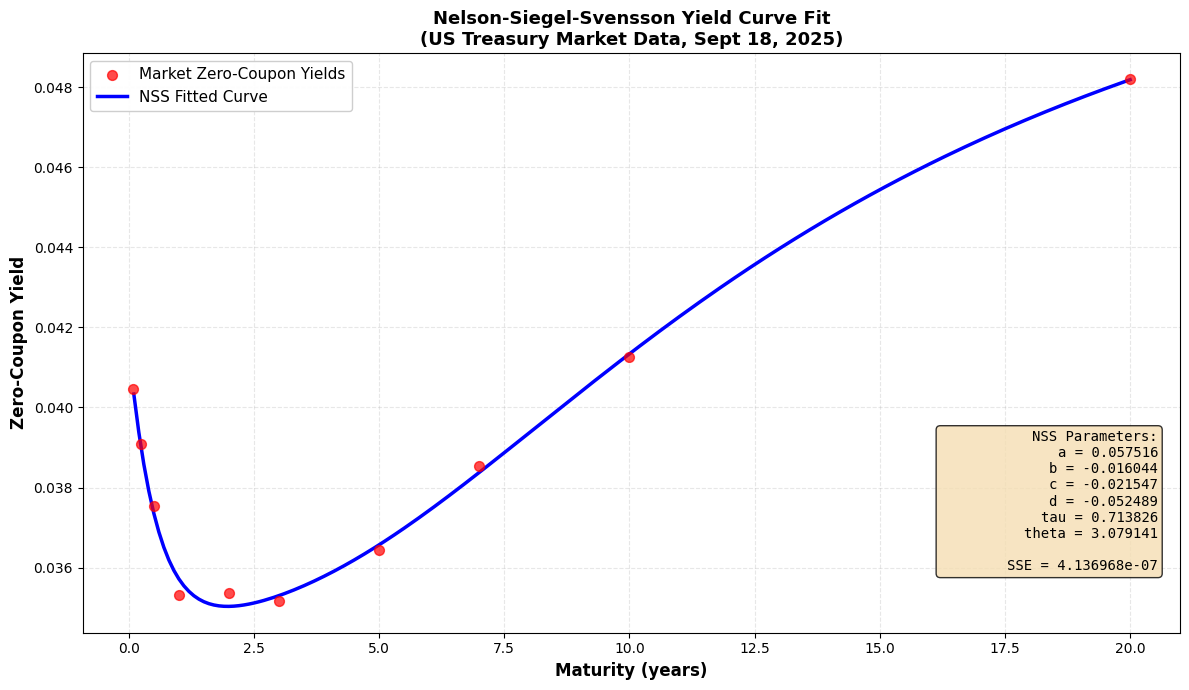

In [2]:
from src.fi_pricing.curves import NSS_Calibrator
import matplotlib.pyplot as plt

# Bounds for NSS parameters
bounds = [
            (-10, 10),       # a
            (-10, 10),       # b
            (-10, 10),       # c
            (-10, 10),       # d
            (0.01, 10),      # tau
            (0.01, 10)       # theta
        ]


# Create calibrator and fit to zero-coupon yields from Q1
calibrator = NSS_Calibrator()
calibrator.fit(zcys, verbose=True, bounds=bounds, strategy= 'best1bin')

# Extract results
nss_fit = calibrator.fitted_curve
params = calibrator.params
opt_result = calibrator.optimization_result


#plot the fit
calibrator.plot_fit(zcys)

### Note:
To find the global optimum, we are using the Differential Evolution optimization technique. We initially ran the optimization with much wider bounds and more exploratory strategies like "rand2bin" and "rand2exp". To reduce computation time for the reader's convenience, we now use the "rand1bin" strategy with refined bounds, decreasing the runtime while maintaining convergence to the same optimal solution. 

***
**3) You are now on September 19, i.e., a fraction $t = 0.003$ of year has elapsed. You observe the following implied volatilities in percentage points on the cap market ($K_f$ stands for the forward swap rate):**

| | $0.85K_f$ | $K_f$ | $1.15K_f$ |
|---|-------|-------|-------|
| 1-yr | 20.90 | 16.62 | 14.28 |
| 2-yr | 24.44 | 22.42 | 19.58 |
| 3-yr | 25.67 | 24.42 | 22.51 |
| 4-yr | 26.02 | 24.95 | 23.48 |
| 5-yr | 26.04 | 24.95 | 23.72 |
| 6-yr | 25.86 | 24.69 | 23.62 |
| 7-yr | 25.37 | 24.09 | 23.15 |
| 8-yr | 25.24 | 23.84 | 23.01 |
| 9-yr | 25.05 | 23.56 | 22.82 |
| 10-yr | 24.82 | 23.21 | 22.57 |

**Let $\Theta$ denote the set of parameters for the two-factor Gaussian model. Do the calibration by solving for the following programme:**

$$\min_{\Theta} \sum_{j=1}^{3} \sum_{k=1}^{10} \left( \frac{cap_{bm}(K_j, T_k) - cap_{mkt}(K_j, T_k)}{cap_{mkt}(K_j, T_k)} \right)^2$$

i.e., minimizing the relative pricing errors on the cap market prices.

Report the parameter values and the value of the minimized objective function.  Plot the quality of the fit on the cap prices as well as on the cap implied volatilities (one 2-D plot for each strike)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, brentq
from src.fi_pricing.models import TwoFactorGaussianModel, BlackCapModel

t = 0.003   # Sep 19 — pricing date
maturities = np.arange(1, 11)   # 1, 2, ..., 10
imp_vols = np.array([
    [20.90, 16.62, 14.28],   # 1-yr
    [24.44, 22.42, 19.58],   # 2-yr
    [25.67, 24.42, 22.51],   # 3-yr
    [26.02, 24.95, 23.48],   # 4-yr
    [26.04, 24.95, 23.72],   # 5-yr
    [25.86, 24.69, 23.62],   # 6-yr
    [25.37, 24.09, 23.15],   # 7-yr
    [25.24, 23.84, 23.01],   # 8-yr
    [25.05, 23.56, 22.82],   # 9-yr
    [24.82, 23.21, 22.57],   # 10-yr
]) / 100

# we assume quarterly payment dates and first reset = t = 0.003
payment_dates_list = [
    np.round(t + np.arange(0.25, k + 1e-9, 0.25), 6)
    for k in maturities
]
print("Payment dates for 1 year maturity Cap (as an example):" + str(payment_dates_list[0]))

# Forward swap rate K_f 
black_model = BlackCapModel(curve=nss_fit)
K_f = black_model.forward_swap_rate(t_alpha=t, payment_dates=payment_dates_list[-1])
strikes = np.array([0.85 * K_f, K_f, 1.15 * K_f])

print(f"Forward swap rate  K_f      = {K_f:.4%}")
print(f"Strikes: 0.85*K_f={strikes[0]:.4%}  K_f={strikes[1]:.4%}  1.15*K_f={strikes[2]:.4%}")


Payment dates for 1 year maturity Cap (as an example):[0.253 0.503 0.753 1.003]
Forward swap rate  K_f      = 4.0933%
Strikes: 0.85*K_f=3.4793%  K_f=4.0933%  1.15*K_f=4.7073%


In [4]:
#  Convert implied vols to cap prices via Black-76 (Eq. 5.10)

mkt_prices = np.zeros((10, 3))

for i, (k, pay_dates) in enumerate(zip(maturities, payment_dates_list)):
    for j, K in enumerate(strikes):
        mkt_prices[i, j] = black_model.cap_price(
            t=t, payment_dates=pay_dates, K=K, sigma_cap=imp_vols[i, j]
        )

# Display table of cap prices ( on notional of 1)
print(f"{'Maturity':>3}  {'0.85*Kf':>9}  {'Kf':>10}  {'1.15*Kf':>12}")
print("-" * 46)
for i, k in enumerate(maturities):
    print(f"{k:5d}  {mkt_prices[i,0]:12.6f}  {mkt_prices[i,1]:12.6f}  {mkt_prices[i,2]:12.6f}")


Maturity    0.85*Kf          Kf       1.15*Kf
----------------------------------------------
    1      0.002538      0.000113      0.000002
    2      0.006352      0.001762      0.000392
    3      0.012242      0.005401      0.002287
    4      0.019735      0.010525      0.005591
    5      0.028745      0.017009      0.010178
    6      0.039165      0.024767      0.015979
    7      0.050548      0.033342      0.022596
    8      0.063531      0.043466      0.030741
    9      0.077295      0.054394      0.039728
   10      0.091536      0.065724      0.049235


In [5]:
from scipy.optimize import differential_evolution, brentq
from src.helpers.two_factor_gaussian_calibration import cap_price_objective, plot_cap_prices, plot_implied_vols

# (a, b, sigma, eta, rho, x_t, y_t)
bounds = [(1e-4, 2.0), (1e-4, 2.0), (1e-4, 0.5), (1e-4, 0.5),
          (-0.9999, 0.9999), (-0.20, 0.20), (-0.20, 0.20)]

de_result = differential_evolution(
    cap_price_objective,
    bounds=bounds,
    args=(nss_fit, mkt_prices, payment_dates_list, strikes, t),
    seed=42, maxiter=5000, popsize=20, tol=1e-9, atol=1e-11,
    strategy='best1bin',  # Faster convergence
    # strategy= 'rand2bin',
    workers=-1,
    updating='deferred',
    recombination= 0.85,
)

a, b, sigma, eta, rho, x_t, y_t = de_result.x
print(f"Converged: {de_result.success}  |  Iterations: {de_result.nit}    |  Evals = {de_result.nfev}\n")
print(f"Optimization Results:  \nObj_fun_val = {de_result.fun:.4e} ")
print(f"a = {a:.5f} \nb = {b:.5f} \nsigma = {sigma:.5f} \neta = {eta:.5f} \nrho = {rho:.5f} \nx_t = {x_t:.5f}  \ny_t = {y_t:.5f}")

two_factor_model = TwoFactorGaussianModel(a=a, b=b, sigma=sigma, eta=eta, rho=rho,
                                           curve=nss_fit, x_t=x_t, y_t=y_t)


Converged: True  |  Iterations: 881    |  Evals = 123624

Optimization Results:  
Obj_fun_val = 4.1949e-02 
a = 0.48292 
b = 0.30938 
sigma = 0.07962 
eta = 0.07811 
rho = -0.99990 
x_t = 0.00922  
y_t = -0.00455


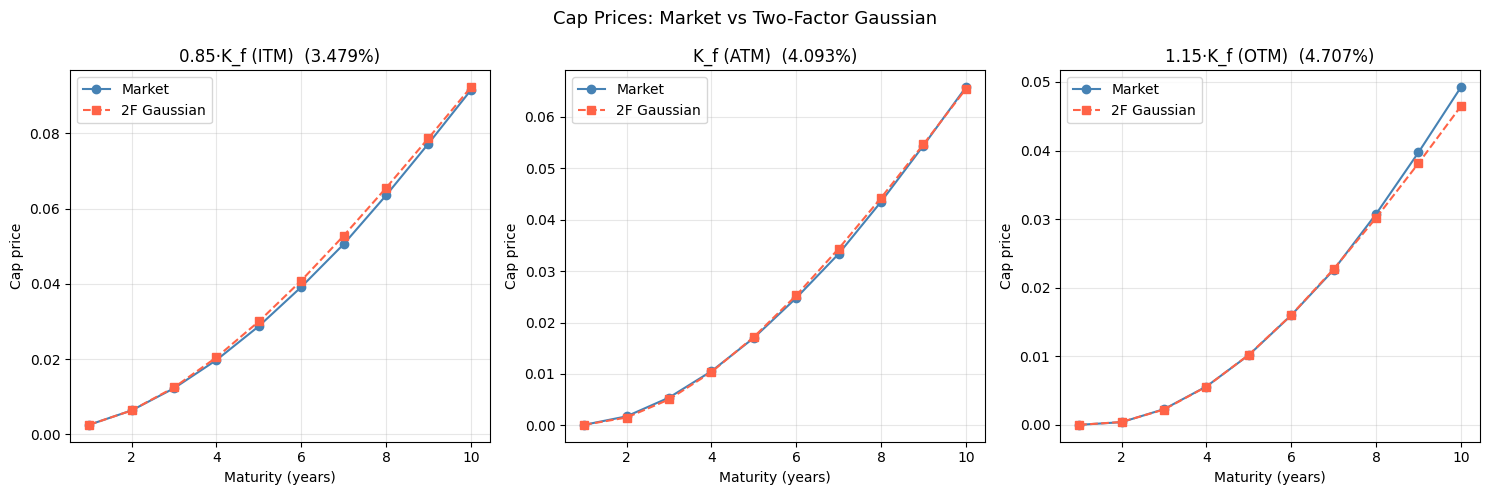

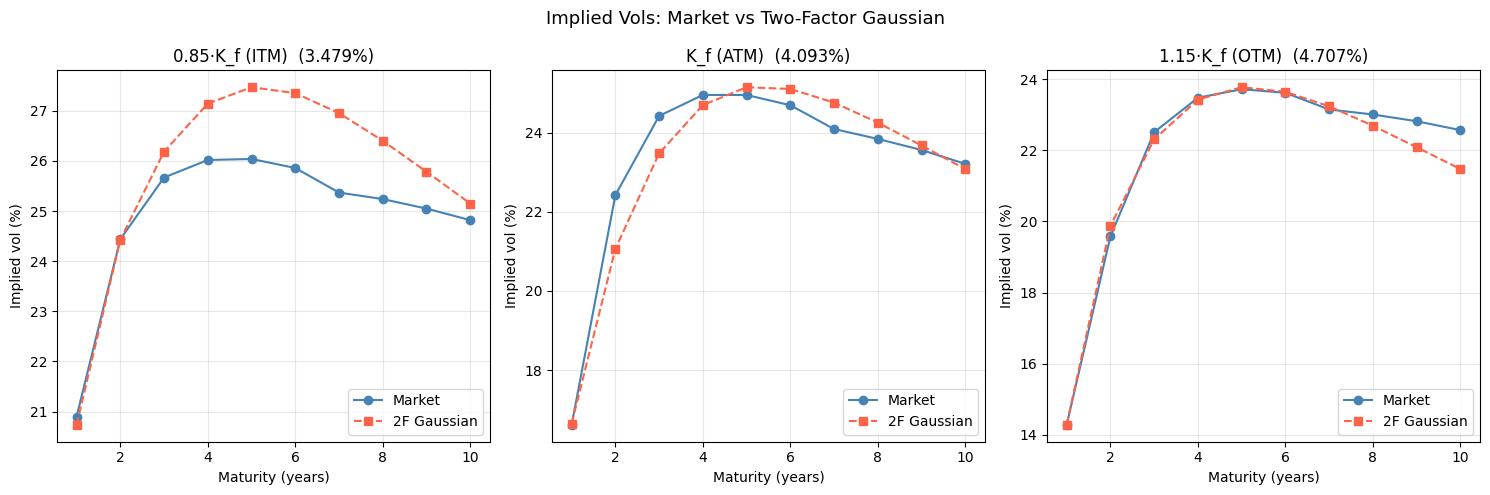

In [6]:
model_prices = two_factor_model.cap_prices_batch(t, payment_dates_list, strikes)

# Invert Black Model to get 2fg model implied vols
model_vols = np.array([
    [brentq(lambda v, pd=pd, K=K, mp=model_prices[i,j]:
            black_model.cap_price(t=t, payment_dates=pd, K=K, sigma_cap=v) - mp,
            1e-6, 5.0)
     for j, K in enumerate(strikes)]
    for i, pd in enumerate(payment_dates_list)
])

plot_cap_prices(maturities, mkt_prices, model_prices, strikes)
plot_implied_vols(maturities, imp_vols, model_vols, strikes)


### Note:

**Calibration Approach:** Used differential evolution (global optimizer with parallelization) to fit all 7 parameters $(a, b, \sigma, \eta, \rho, x_t, y_t)$ simultaneously to 30 market cap prices. We calibrate $x_t$ and $y_t$ (factor states) alongside structural parameters because are fitting cap prices at $t=0.003$ and not at $t=0$.

**Results:** The model achieves a reasonable fit to market cap prices. However, the calibrated correlation parameter $\rho \approx -1$ (at the boundary) is not pleasing though —it suggests the parameter is not effectively utilized by the model.

---
## PART TWO

### Question 1
**1) The Excel file contains the Nelson-Siegel-Svensson coefficients published by the St-Louis Federal Reserve Bank (Wednesday or Thursday if Wednesday is a holiday) for the period from August 2019 – January 2026 period. Construct the weekly zero-coupon yield series for the 3 months, 6 months, 1-year, 2-year, and 3-year maturities. For each observation, plot the yield curves with your estimated parameters (use the quarterly and yearly durations: 3 months, 6 months, 1 year, 2 year, and 3 years for the five observations describing the first and third quarters of the series.**

In [7]:
# Load Excel data
import sys, os
# make sure the notebook / script is run from the repo root
sys.path.insert(0, os.path.abspath("src"))

import fi_pricing
import inspect
import importlib
import part2.analysis as analysis
importlib.reload(analysis) # ensure latest module changes are picked up


<module 'part2.analysis' from 'c:\\Users\\navid\\Documents\\GitHub\\Fixed_Income_A1\\src\\part2\\analysis.py'>

In [8]:
%matplotlib inline

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from part2.analysis import Part2Config, Part2Solver

# adjust repo root as needed
REPO_ROOT = Path(".").resolve()
cfg = Part2Config(
    repo_root=REPO_ROOT,
    excel_path=REPO_ROOT / "Data" / "TP1_data.xlsx",
)
solver = Part2Solver(cfg)

In [9]:
# Construct zero-coupon yield series
weekly_df = solver.weekly.df if solver.weekly is not None else solver.compute_weekly()
stats_df = solver.stats if solver.stats is not None else solver.compute_stats()
print("Descriptive statistics for each maturity:")
display(stats_df)

Descriptive statistics for each maturity:


,Maturity,Mean,Std,Q1,Median,Q3
0,3M,2.842952,2.160096,0.218009,3.639531,4.931027
1,6M,2.815641,2.090582,0.219845,3.689847,4.789102
2,1Y,2.752599,1.976020,0.245916,3.579286,4.539148
3,3Y,2.641048,1.671097,0.733470,3.474668,4.093740
4,5Y,2.678781,1.513737,1.115698,3.436988,3.993853
5,10Y,2.925587,1.384548,1.617464,3.435139,4.224936
6,30Y,3.432659,1.224451,2.237609,3.757467,4.568139


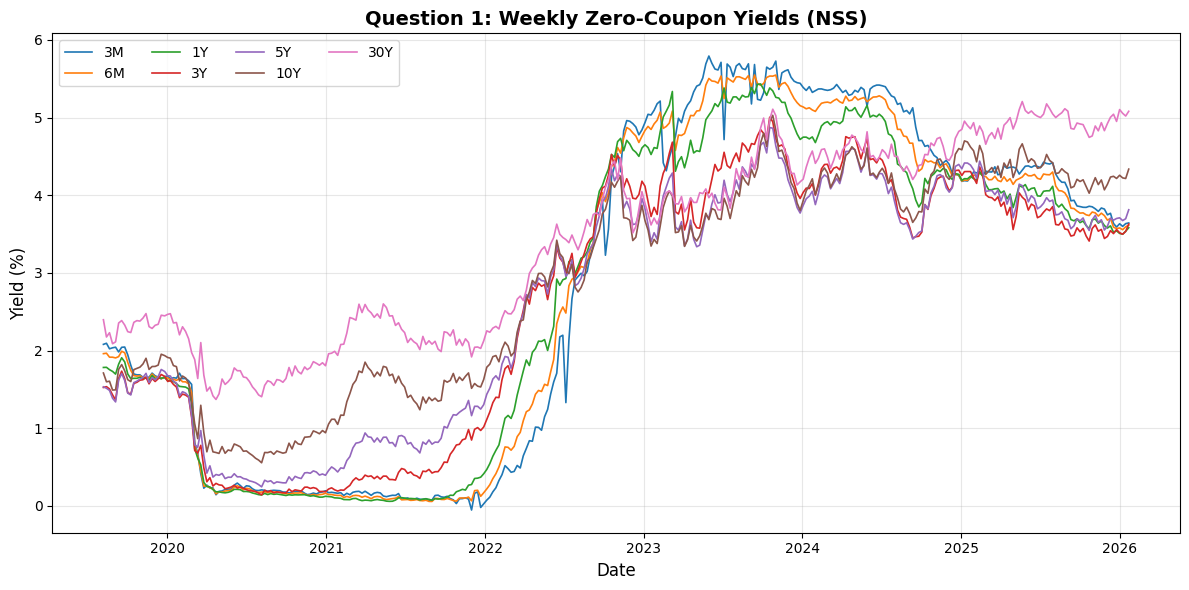

In [10]:
# Plot yield curves
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Extract the weekly yields dataframe
weekly_df = solver.weekly.df

# 2. Set up the figure
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Plot a line for each of the 7 maturities
for label in cfg.labels:
    ax.plot(weekly_df["Date"], weekly_df[label], label=label, linewidth=1.2)

# 4. Format the graph to make it look professional
ax.set_title("Question 1: Weekly Zero-Coupon Yields (NSS)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Yield (%)", fontsize=12)

# Set the legend in the upper left with multiple columns so it doesn't block the lines
ax.legend(loc="upper left", ncol=4, fontsize=10)
ax.grid(True, alpha=0.3)

# Format the X-axis to show just the years clearly
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

**Interpretation:**

Based on the empirical data and the descriptive statistics table, the evolution of the Nelson-Siegel-Svensson (NSS) zero-coupon yields exhibits several key structural dynamics:
1. Volatility Structure: The descriptive statistics perfectly illustrate the theoretical property that yields with shorter maturities exhibit higher volatility over time. The short end of the curve is highly volatile. In contrast, the long end is much more stable, anchoring the curve with the 30-year yield. This volatility differential explains why the short end acts as the primary driver of changes in the curve's slope.
2. Yield Curve Geometry (Level and Slope):
Increasing / Normal Shape (2020 - 2021): Following an initial drop, the overall level of the yield curve falls to its lowest point. During this period, the curve exhibits a classic "increasing" shape, with the short end bounded near 0% while the long end (10Y and 30Y) remains anchored between 1.5% and 2.5%. According to theory, this steep, upward-sloping geometry is typically associated with economic recovery phases where long-term money demand increases.
Level Shift and Inversion (2022 - 2024): Starting in 2022, there is a violent upward shift in the overall level of the curve. Because the short-end maturities are far more volatile, their yields accelerate much faster than the long end, causing a severe slope inversion. By 2023, the 3M and 6M yields peak near 5.5%–6.0%, crossing significantly above the 10Y and 30Y yields. This "decreasing" yield curve shape is the textbook signature of a restrictive monetary environment and a contractionary phase of the business cycle.
Normalization (2025 - 2026): Towards the end of the sample, the extreme negative slope begins to neutralize. The highly volatile short-term rates drop back toward the 3.5%–4.0% range, converging with the long end and flattening the curve.

### Question 2
**2) Apply a maximum likelihood Cox-Ingersoll-Ross estimation with the weekly data. On a first table report the values of the estimated parameters, their standard errors and the errors for each maturity. On a second table, compare this path followed by the estimated instantaneous risk-free rate process. Compare this path with the one followed by the Nelson-Siegel-Svensson short-term rate (that should also be reported and plotted on the same graph).**

In [11]:
# Maximum likelihood estimation for CIR model
import pandas as pd
import numpy as np

# ensure the CIR model is estimated before trying to read results
fit = solver.estimate_cir()
# also keep the short‑rate path handy for later plotting
cir_path = solver.r_path

# defensive access in case an older `fit` object (from a stale kernel) lacks new fields
lambda_risk = getattr(fit, "lambda_risk", np.nan)
se_params = getattr(fit, "se_params", np.full(5, np.nan))

# guard se_params length
if se_params is None:
    se_params = np.full(5, np.nan)
else:
    se_params = np.asarray(se_params, dtype=float)
    if se_params.size < 5:
        tmp = np.full(5, np.nan)
        tmp[: se_params.size] = se_params
        se_params = tmp

params = pd.DataFrame([{
    "kappa": getattr(fit, "kappa", np.nan),
    "theta": getattr(fit, "theta", np.nan),
    "sigma": getattr(fit, "sigma", np.nan),
    "lambda_risk": lambda_risk,
    "se_kappa": se_params[0],
    "se_theta": se_params[1],
    "se_sigma": se_params[2],
    "se_lambda": se_params[4],
    "max_loglik": getattr(fit, "max_loglik", np.nan),
}])
print("Estimated CIR parameters:")
display(params)

errs = pd.DataFrame({
    "Maturity": cfg.labels,
    "MeanError": solver.innovations.mean(axis=0),
    "VarError": solver.innovations.var(axis=0, ddof=1),
})
print("Measurement error statistics:")
display(errs)

Estimated CIR parameters:


,kappa,theta,sigma,lambda_risk,se_kappa,se_theta,se_sigma,se_lambda,max_loglik
0,0.073676,0.046942,0.065041,-4.551792,0.0,0.0,1.539868,2.791726e-07,8629.189675


Measurement error statistics:


,Maturity,MeanError,VarError
0,3M,0.000643,0.000004
1,6M,0.000199,0.000001
2,1Y,-0.000761,0.000006
3,3Y,-0.003034,0.000026
4,5Y,-0.003594,0.000031
5,10Y,-0.002773,0.000029
6,30Y,-0.000110,0.000044


**Note:** The standard errors for κ and θ evaluate to 0.0. This occurs because the finite-difference approximation of the Hessian matrix suffers from numerical instability and floating-point cancellation on the flat likelihood surface. The covariance matrix safety net (np.maximum(..., 0.0)) clips the resulting negative variances to zero.

### Question 3
**3) Plot the path followed by the estimated instantaneous risk-free rate process. Compare this path with the one followed by the Nelson-Siegel-Svensson short-term rate (that should also be reported and plotted on the same graph).**

In [12]:
# compute NSS short rate for each date
from part2.analysis import nss_instantaneous_short_rate_percent
nss_sr = nss_instantaneous_short_rate_percent(solver.nss.df)

# dates align with solver.weekly.dates
dates = solver.weekly.dates
print("first few NSS short rates:", nss_sr[:5])

first few NSS short rates: [2.22528293 2.25511529 2.15395502 2.18133369 2.20953932]


# Plot and Compare Rate Path

The two short‑rate series are plotted on the same axes for visual comparison.

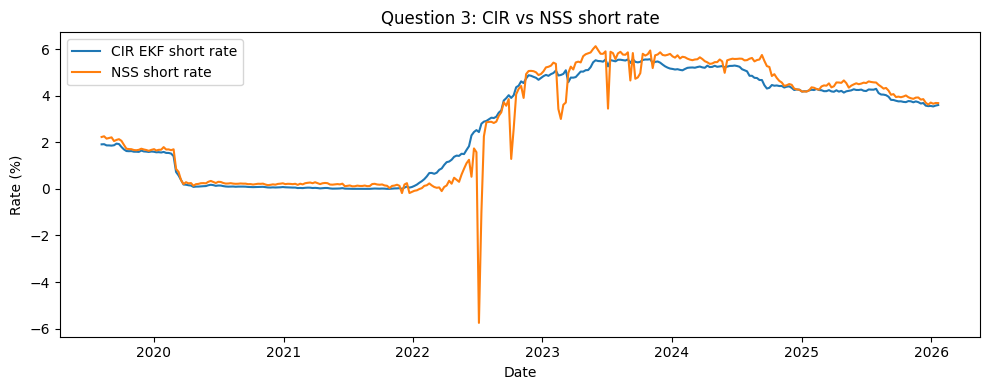

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(dates, cir_path* 100, label="CIR EKF short rate")
plt.plot(dates, nss_sr, label="NSS short rate")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.title("Question 3: CIR vs NSS short rate")
plt.tight_layout()
plt.show()


**Interpretation of the results:**

The graph shows that both the CIR estimated rate and the NSS short rate follow the same general macro trend—dropping to near zero in 2020 and climbing back up to around 4-5% by 2023. However, the NSS rate experiences a massive, unrealistic plunge down to around -6% in mid-2022, while the CIR rate remains smooth and strictly positive.
This extreme drop in the NSS rate is essentially a mathematical artifact. The Fed calibrates the NSS parameters to fit observable maturities (like 1 to 30 years), not the theoretical instantaneous limit where T approaches 0. When the yield curve gets heavily inverted, the BETA1 coefficient becomes extremely negative to force the curve to fit the slope, which drags the theoretical short rate (BETA0 + BETA1) well below zero.
The CIR model filters out this noise perfectly. By design, its square-root volatility process (σ sqrt(rt)) and the Feller condition mathematically prevent the interest rate from ever crossing into negative territory. Furthermore, the built-in mean reversion of the CIR model naturally smooths out the trajectory, giving us a much more realistic and stable path for the short rate than the raw NSS extrapolation.